# Lab 2 Solution: Gaussian process regression in BoTorch and GPyTorch
BoTorch is a package for Bayesian Optimization.  Its support for Gaussian process regression comes from another package, `GPyTorch`.  Both of these packages are, in turn, based on `PyTorch`, which is a framework often used for deep learning that supports fast operations on GPUs in python.

Here we'll use these packages to do the same inference that we did above, but more quickly and with more features.  The format for this portion of the tutorial is based on the BoTorch tutorial, https://botorch.org/tutorials/fit_model_with_torch_optimizer, which in turn seems to be based on the gpytorch tutorial, https://github.com/cornellius-gp/gpytorch/blob/master/examples/01_Exact_GPs/Simple_GP_Regression.ipynb

In [55]:
import torch # loading torch before matplotlib can be important
import matplotlib.pyplot as plt
import numpy as np
import os

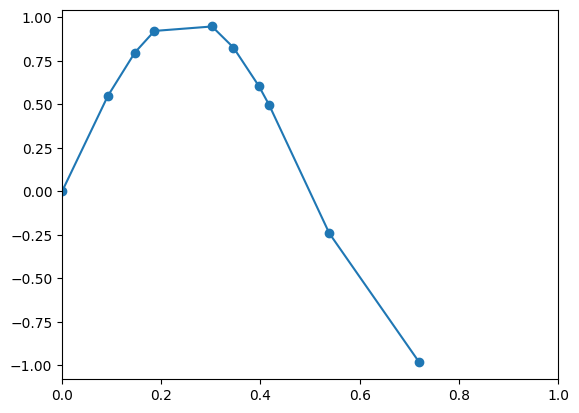

In [56]:
filename = 'lab1_data.csv'
data = np.loadtxt(filename)
train_x = data[:,0] # First column of the data
train_y = data[:,1] # Second column of the data
#plt.xlim(0,1)
#plt.plot(train_x, train_y,'o-')

fig, ax = plt.subplots()
ax.set_xlim(0,1)
ax.plot(train_x, train_y,'o-')

plt.show()

In [57]:
# use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double

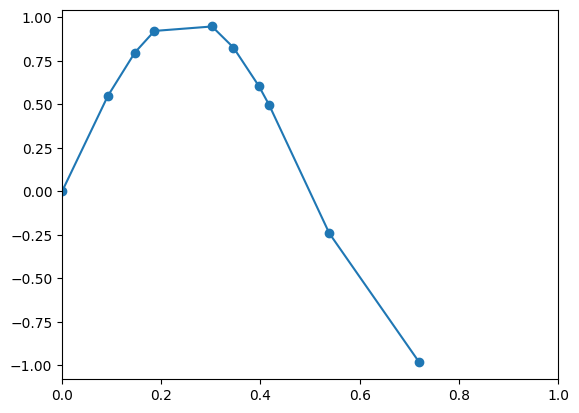

In [58]:
# Read in data from a file.  Code copied from Lab 1.
filename = 'lab1_data.csv'

# If data doesn't exist, generate it
if not os.path.exists(filename):
    rng = np.random.default_rng(seed=0) # For reproducibility
    train_x = np.sort(rng.random((10,))) # 10 points, uniformly distributed between 0 and 1
    train_y = [np.sin(x * (2 * np.pi)) + 0.0 * rng.standard_normal() for x in train_x]
    data = np.transpose([train_x,train_y])
    np.savetxt(filename,data)

# Read in data from a file.  
data = np.loadtxt(filename)
train_x = data[:,0] # First column of the data
train_y = data[:,1] # Second column of the data

fig, ax = plt.subplots()
ax.set_xlim(0,1)
ax.plot(train_x, train_y,'o-')
#plt.xlim(0,1)
#plt.plot(train_x, train_y,'o-')

### Convert training data to torch format

In [59]:
# Convert our training x and y data to torch format.
# To do this, we first convert to a torch tensor.
# Then we use unsqueeze to make the tensors multidimensional.
# Note that we are changing the datatype of train_x and train_y
train_x = torch.from_numpy(train_x).unsqueeze(1).to(device=device, dtype=dtype)
train_y = torch.from_numpy(train_y).unsqueeze(1).to(device=device, dtype=dtype)

# Outputting one of these tensors to show what they look like
train_x

tensor([[1.1437e-04],
        [9.2339e-02],
        [1.4676e-01],
        [1.8626e-01],
        [3.0233e-01],
        [3.4556e-01],
        [3.9677e-01],
        [4.1702e-01],
        [5.3882e-01],
        [7.2032e-01]], dtype=torch.float64)

### Train the GP regression model and plot the posterior
We will model the function using a `SingleTaskGP`, which by default uses a `GaussianLikelihood` and infers the unknown noise level.

The default optimizer for the `SingleTaskGP` is L-BFGS-B, which takes as input explicit bounds on the noise parameter. However, the `PyTorch` optimizers don't support parameter bounds as input. To use the `PyTorch` optimizers, then, we'll need to manually register a constraint on the noise level. When registering a constraint, the `softplus` transform is applied by default, enabling us to enforce a lower bound on the noise.

**Note**: Without manual registration, the model itself does not apply any constraints, due to the interaction between constraints and transforms. Although the `SingleTaskGP` constructor does in fact define a constraint, the constructor sets `transform=None`, which means that the constraint is not enforced. See the [GPyTorch constraints module](https://github.com/cornellius-gp/gpytorch/blob/master/gpytorch/constraints/constraints.py) for additional information.


In [60]:
from botorch.models import SingleTaskGP
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from gpytorch.constraints import Positive
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.means import ZeroMean, ConstantMean

# Create a likelihood appropriate for noise-free observations.
# We will use a Gaussian likelihood with a very small variance (noisefree_variance).
# We use a small strictly positive variance instead of zero variance
# to avoid numerical instabilities. If, instead, we set noisefree_variance to 0, 
# then gpytorch would issue warning messages and round up to a small positive number.
noisefree_variance = 0.0001
noises = torch.ones(len(train_y)) * noisefree_variance
noise_free_likelihood = FixedNoiseGaussianLikelihood(noise=noises)

# Covariance kernel with Matern kernel (nu=2.5)
# In this case we impose a constraint on the lengthscale parameter
covar_module = ScaleKernel(MaternKernel(nu=2.5, 
                                        lengthscale_constraint=GreaterThan(1e-3),
                                        raw_lengthscale_constraint=Positive()
                                        ),
                            raw_outputscale_constraint=Positive(),
)

# Mean function is set to 0
mean_module = ConstantMean()

# Create our GP model using the training data and the set up we're using
# for the mean function, covariance kernel, and likelihood.
model = SingleTaskGP(train_x, 
                     train_y,
                     covar_module=covar_module,
                     mean_module=mean_module, 
                     likelihood = noise_free_likelihood)

# Another slightly faster way to do the same thing is:

# from botorch.models import FixedNoiseGP
# model = FixedNoiseGP(torch_train_x, torch_train_y, noises)

# If you want to allow BoTorch to learn the variance of homoscedastic Gaussian noise, drop the likelihood argument as in 
# model = SingleTaskGP(train_x, train_y, likelihood = noise_free_likelihood, covar_module=covar_module, mean_module=mean_module)

model

SingleTaskGP(
  (likelihood): FixedNoiseGaussianLikelihood(
    (noise_covar): FixedGaussianNoise()
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): MaternKernel(
      (raw_lengthscale_constraint): GreaterThan(1.000E-03)
    )
    (raw_outputscale_constraint): Positive()
  )
  (outcome_transform): Standardize()
)

You can see from the output above that the GP model has several components:
- a likelihood, which describes the likelihood of our observation in terms of the value of the underlying function we want to estimate. We assume that our observations are normally distributed with a mean equal to the function's true value, and a very small variance. One can also assume that we observe the function without noise, but this creates some numerical instabilities in `GPyTorch`.
- a mean and covar module, which specifies the mean and kernel function respectively

The covar module has a constraint on its lengthscale saying that it must be positive, and also has a prior that is used when estimating it from data.  For now, we will simply use a fixed length scale and so this constraint and prior won't matter for the moment.

Now we change the parameters used in the prior to match what we used in Session 4 as a default.  The constant for the mean because it is 0 by default. Then we can fit the model and see that BoTorch is doing the same thing that we did earlier.

In [61]:
# Set the mean to a constant value
# Here we set it to 0.0, but you can try other values.
model.mean_module.constant =  torch.tensor(0.)

# GPyTorch only supports these values for the nu parameter for the Matern kernel: 1/2, 3/2, or 5/2
# If you want to use the value 2, this is supported through the RBF Kernel.
# (The RBF kernel is the Matern kernel with nu=2).
model.covar_module.base_kernel.nu = 2.5

# It determines the length scale of the output.
model.covar_module.base_kernel.lengthscale = 1.

# model.covar_module.outputscale is what we call alpha0
model.covar_module.outputscale = 1.

# Train the GP model
model.eval()


SingleTaskGP(
  (likelihood): FixedNoiseGaussianLikelihood(
    (noise_covar): FixedGaussianNoise()
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): MaternKernel(
      (raw_lengthscale_constraint): GreaterThan(1.000E-03)
    )
    (raw_outputscale_constraint): Positive()
  )
  (outcome_transform): Standardize()
)

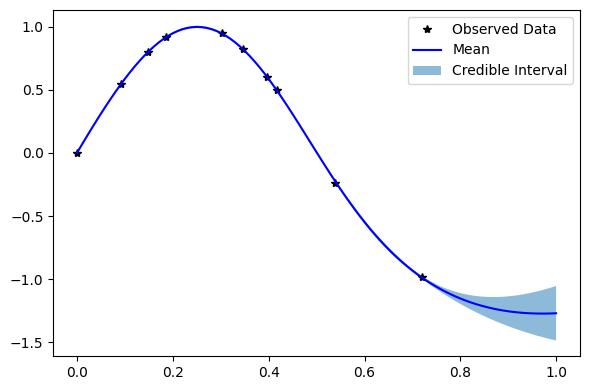

In [62]:
def plot_posterior(model):

    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(6, 4))
    # test model on 101 regular spaced points on the interval [0, 1]
    test_x = torch.linspace(0, 1, 101, dtype=dtype, device=device)

    with torch.no_grad(): # no need for gradients
        # compute posterior
        posterior = model.posterior(test_x)
        # Get upper and lower confidence bounds (2 standard deviations from the mean)
        lower, upper = posterior.mvn.confidence_region()
        # Plot training points as black stars
        ax.plot(train_x.cpu().numpy(), train_y.cpu().numpy(), 'k*')
        # Plot posterior means as blue line
        ax.plot(test_x.cpu().numpy(), posterior.mean.cpu().numpy(), 'b')
        # Shade between the lower and upper confidence bounds
        ax.fill_between(test_x.cpu().numpy(), lower.cpu().numpy(), upper.cpu().numpy(), alpha=0.5)
        
    ax.legend(['Observed Data', 'Mean', 'Credible Interval'])
    plt.tight_layout()
    
plot_posterior(model)

You should see that this plot matches very closely with the plot that we got in Session 4 using the default parameters:

`plot_prediction()`

#### Exercise 1

Using BoTorch, reproduce the figure that you generated in Session 4 with this code

`plot_prediction(
    mean = lambda x : -0.5,
    kernel = CustomMaternKernel(alpha0=20, length_scales=1.0, nu = 1.5))`

#### Exercise 1 Solution

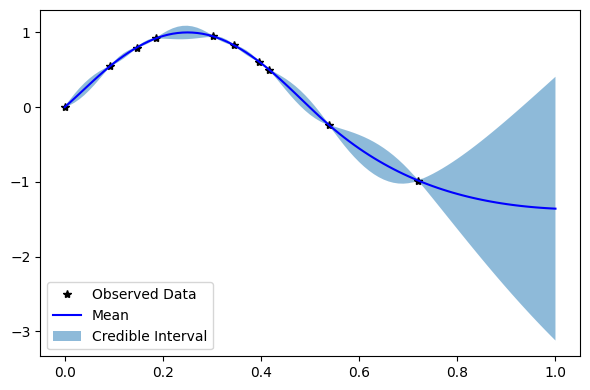

In [63]:
model = SingleTaskGP(train_x, 
                     train_y, 
                     likelihood = noise_free_likelihood,
                     covar_module=covar_module,
                     mean_module=mean_module)

# Set initial values of the Matern kernel hyperparameters
model.covar_module.base_kernel.nu = 1.5
model.covar_module.base_kernel.lengthscale = 1
model.covar_module.outputscale = 20.

# Set the mean to a constant value
model.mean_module.constant = torch.tensor(-0.5)

# Train the GP model
model.eval()

plot_posterior(model)

#### End Exercise 1

# Choosing the GP hyperparameters

Here we show how to optimize the GP hyperparameters (the lengthscale and constant mean of the prior --- nu will remain fixed) based on the log marginal likelihood.  Here we will show you how to do this manually, explaining all of the steps, and then below we'll show a function that does all of this for you. 

### Start with a fresh Gaussian process, that doesn't have the parameters we set above

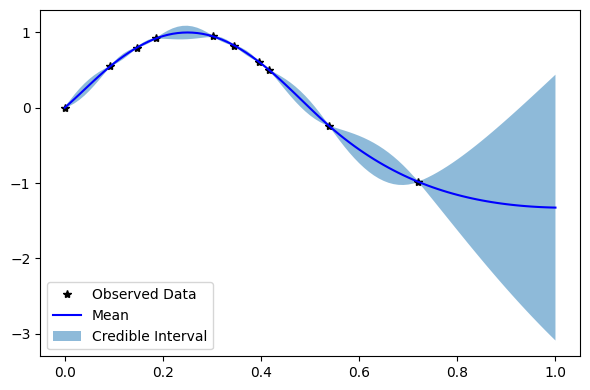

In [64]:
model = SingleTaskGP(train_x, train_y, likelihood = noise_free_likelihood,
                     covar_module=covar_module,
                     mean_module=ConstantMean())
model.eval()

plot_posterior(model)

#### Define marginal log likelihood  (mll)

In [65]:
from gpytorch.mlls import ExactMarginalLogLikelihood

mll = ExactMarginalLogLikelihood(likelihood=model.likelihood, model=model)

# set mll and all submodules to the numeric data type and device (GPU vs. CPU) specified at the start of 
# our BoTorch code.
mll = mll.to(train_x)

#### Define optimizer and specify hyperparameters to optimize
We will use stochastic gradient descent (`torch.optim.SGD`) to optimize the hyperparameters. In this example, we will use a simple fixed learning rate of 0.2, but in practice the learning rate may need to be adjusted. We will optimize over all parameters in the model, though one could pass a subset of the parameters to the model to tune only those while leaving the others fixed.

In [66]:
from torch.optim import SGD

optimizer = SGD([{'params': model.parameters()}], lr=0.2)

The following code allows us to look at the names of the parameters in the GP regression model that will be optimized.  Note that the lengthscale is outputted with a "raw" prepended to them. `GPyTorch` wants to ensure that certain parameters (like the lengthscale) satisfy constraints (specifially, that they are positive). To do this, it maintains a raw version of these parameters that can be any real number, and a transformed version that satisfies the constraint.  For example, to satisfy a non-negativity constraint, one can have the transformed version be exp() applied to the raw parameter.  The parameter nu is not included in the parameters that BoTorch optimizes.

In [67]:
print('These are the parameters we will optimize over:')
for param_name, param in model.named_parameters():
    print(param_name)

These are the parameters we will optimize over:
mean_module.raw_constant
covar_module.raw_outputscale
covar_module.base_kernel.raw_lengthscale


#### Optimize hyperparameters
Now we are ready to write our optimization loop. We will perform 1500 epochs of stochastic gradient descent using our entire training set.

In [68]:
NUM_EPOCHS = 1500

model.train()

for epoch in range(NUM_EPOCHS):
    # clear gradients
    optimizer.zero_grad()
    # forward pass through the model to obtain the output MultivariateNormal
    output = model(train_x)
    # Compute the negative marginal log likelihood
    loss = - mll(output, model.train_targets)
    # Use backward propagation to update the model's 
    loss.backward()
    # print every 10 iterations
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS} - Negative Marginal Log Likelihood : {loss.item():>4.3f} "
            f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():>4.3f} " 
            f"outputscale: {model.covar_module.outputscale.item():>4.3f} "
            f"constant: {model.mean_module.constant.item():>4.3f} " 
         )
    optimizer.step()

Epoch  10/1500 - Negative Marginal Log Likelihood : 0.014 lengthscale: 1.252 outputscale: 19.986 constant: -0.034 
Epoch  20/1500 - Negative Marginal Log Likelihood : 0.011 lengthscale: 1.297 outputscale: 19.981 constant: -0.074 
Epoch  30/1500 - Negative Marginal Log Likelihood : 0.010 lengthscale: 1.302 outputscale: 19.978 constant: -0.113 
Epoch  40/1500 - Negative Marginal Log Likelihood : 0.009 lengthscale: 1.303 outputscale: 19.975 constant: -0.153 
Epoch  50/1500 - Negative Marginal Log Likelihood : 0.008 lengthscale: 1.303 outputscale: 19.972 constant: -0.192 
Epoch  60/1500 - Negative Marginal Log Likelihood : 0.007 lengthscale: 1.303 outputscale: 19.969 constant: -0.231 
Epoch  70/1500 - Negative Marginal Log Likelihood : 0.007 lengthscale: 1.303 outputscale: 19.966 constant: -0.269 
Epoch  80/1500 - Negative Marginal Log Likelihood : 0.006 lengthscale: 1.304 outputscale: 19.963 constant: -0.306 
Epoch  90/1500 - Negative Marginal Log Likelihood : 0.005 lengthscale: 1.304 out

In [69]:
# set model (and likelihood)
model.eval()

SingleTaskGP(
  (likelihood): FixedNoiseGaussianLikelihood(
    (noise_covar): FixedGaussianNoise()
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): MaternKernel(
      (raw_lengthscale_constraint): GreaterThan(1.000E-03)
    )
    (raw_outputscale_constraint): Positive()
  )
  (outcome_transform): Standardize()
)

lengthscale: 1.305 outputscale: 19.341 constant: -2.852 nu:  1.5


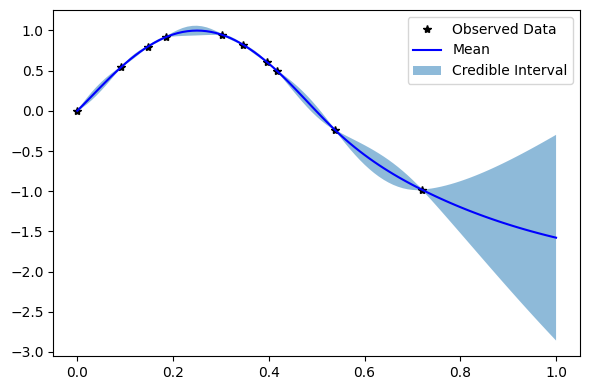

In [70]:
plot_posterior(model)
print(
    f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():>4.3f} "
    f"outputscale: {model.covar_module.outputscale.item():>4.3f} " 
    f"constant: {model.mean_module.constant.item():>4.3f} "
    f"nu: {model.covar_module.base_kernel.nu:>4.1f}"
)

### Here is a faster way to do the same thing 
This uses a BoTorch helper function, fit_gpytorch_model, that isn't in gpytorch

In [71]:
from botorch.fit import fit_gpytorch_mll
model = SingleTaskGP(train_x, train_y, likelihood = FixedNoiseGaussianLikelihood(noise=noises),
                     covar_module=covar_module,
                     mean_module=ConstantMean())
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll) # This chooses the hyperparameters to maximize the log marginal likelihood

ExactMarginalLogLikelihood(
  (likelihood): FixedNoiseGaussianLikelihood(
    (noise_covar): FixedGaussianNoise()
  )
  (model): SingleTaskGP(
    (likelihood): FixedNoiseGaussianLikelihood(
      (noise_covar): FixedGaussianNoise()
    )
    (mean_module): ConstantMean()
    (covar_module): ScaleKernel(
      (base_kernel): MaternKernel(
        (raw_lengthscale_constraint): GreaterThan(1.000E-03)
      )
      (raw_outputscale_constraint): Positive()
    )
    (outcome_transform): Standardize()
  )
)

lengthscale: 0.781 outputscale: 4.859 constant: -2.173 nu:  1.5


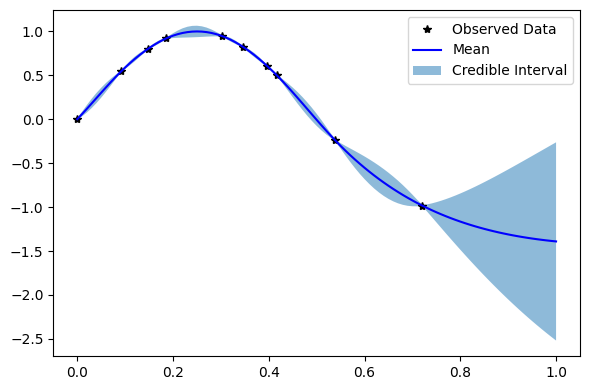

In [72]:
plot_posterior(model)
print(
    f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():>4.3f} "
    f"outputscale: {model.covar_module.outputscale.item():>4.3f} "
    f"constant: {model.mean_module.constant.item():>4.3f} "
    f"nu: {model.covar_module.base_kernel.nu:>4.1f}"
)

# Cross-validation
The following cross-validation plots are for checking model fit.  

In [73]:
# Helper function for cross-validation
def remove(T,i):
    # Remove the ith component from the 1-dimensional tensor T
    assert(i<len(T))
    return torch.cat([T[:i], T[i+1:]])

# Check that we handle the two corner cases where i is 0 or len-1
assert(len(remove(train_x,0))==9)
assert(len(remove(train_x,len(train_x)-1))==9)
assert(len(remove(train_x,5))==9)

In [74]:
remove(train_y,1)

tensor([[ 7.1864e-04],
        [ 7.9687e-01],
        [ 9.2087e-01],
        [ 9.4643e-01],
        [ 8.2510e-01],
        [ 6.0409e-01],
        [ 4.9807e-01],
        [-2.4148e-01],
        [-9.8267e-01]], dtype=torch.float64)

In [75]:
def cross_validation(train_x,train_y,nu=1.5):
    loo_mean = []
    loo_sdev = []

    for i in range(len(train_x)):
        
        # Remove the ith datapoint from the training set
        loo_train_x = remove(train_x,i)
        loo_train_y = remove(train_y,i)
        noisefree_variance = 0.0001
        noises = torch.ones(len(loo_train_y)) * noisefree_variance
            
        model = SingleTaskGP(loo_train_x, 
                             loo_train_y, 
                             likelihood = FixedNoiseGaussianLikelihood(noise=noises),
                             covar_module=MaternKernel(nu=nu, lengthscale_constraint=GreaterThan(1e-3)),
                             mean_module=ConstantMean())
        
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll) 
    
        posterior = model.posterior(train_x[i].unsqueeze(0))
        # the posterior mean and variance are 2-d 1x1 tensors.  
        # We just need to pull out the single number inside each, which is at index [0][0]
        m = posterior.mean.cpu().detach().numpy()[0][0]
        v = posterior.variance.cpu().detach().numpy()[0][0]
        
        loo_mean.append(m)
        loo_sdev.append(np.sqrt(v))
    
    fig, ax = plt.subplots()
    train_y_np = train_y.cpu().detach().numpy()[:,0]

    ax.errorbar(train_y_np,loo_mean,loo_sdev,fmt='o')
    ax.plot([min(train_y_np),max(train_y_np)],[min(train_y_np),max(train_y_np)],'k--')
    plt.xlabel('observed y')
    plt.ylabel('predicted y')

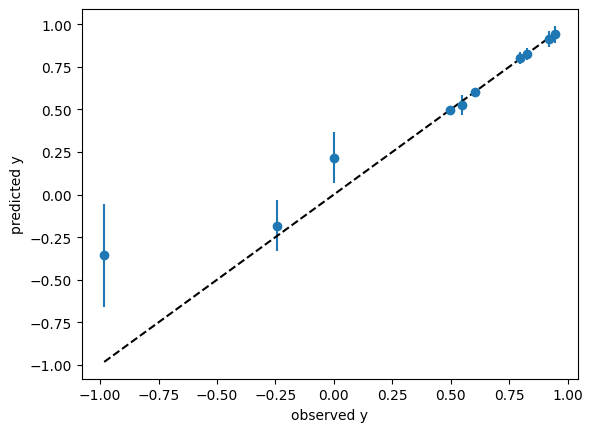

In [41]:
cross_validation(train_x,train_y)

We want to see that the error bar crosses the dashed line for most of the datapoints (95% of the datapoints), and when it misses it shouldn't miss by too much.  This plot looks pretty good.

#### Exercise 2 
    
Using the function below (which is -1 times a standard test function called `Hartmann6`), and the 50 training points generated below (uniformly over the unit cube), fit GP regression using a Matern kernel with `nu=.5` and no noise in the observations.

Choose the hyperparameters by maximizing the log marginal likelihood.

Then plot a cross-validation plot.  You'll see that it looks ok, but some error bars are far from touching the line.  Based on this plot we might want consider another kernel or transforming the objective.

In [42]:
from botorch.test_functions import Hartmann
f = Hartmann(negate=True).to(device=device)


np.random.seed(1)
torch.manual_seed(1)
train_x:torch.Tensor = torch.rand(50, 6, device=device, dtype=dtype)
train_y:torch.Tensor = f(train_x).unsqueeze(-1)  # add output dimension

#### Exercise 2 Solution

In [43]:
noisefree_variance = 0.0001
noises = torch.ones(len(train_y)) * noisefree_variance
model = SingleTaskGP(train_x, train_y, 
                     likelihood = FixedNoiseGaussianLikelihood(noise=noises),
                     covar_module=ScaleKernel(MaternKernel(nu=1.5, 
                                                           lengthscale_constraint=GreaterThan(1e-3), 
                                                           raw_lengthscale_constraint=Positive()),
                                                           raw_outputscale_constraint=Positive()),
                     mean_module=ConstantMean())

mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

ExactMarginalLogLikelihood(
  (likelihood): FixedNoiseGaussianLikelihood(
    (noise_covar): FixedGaussianNoise()
  )
  (model): SingleTaskGP(
    (likelihood): FixedNoiseGaussianLikelihood(
      (noise_covar): FixedGaussianNoise()
    )
    (mean_module): ConstantMean()
    (covar_module): ScaleKernel(
      (base_kernel): MaternKernel(
        (raw_lengthscale_constraint): GreaterThan(1.000E-03)
      )
      (raw_outputscale_constraint): Positive()
    )
    (outcome_transform): Standardize()
  )
)

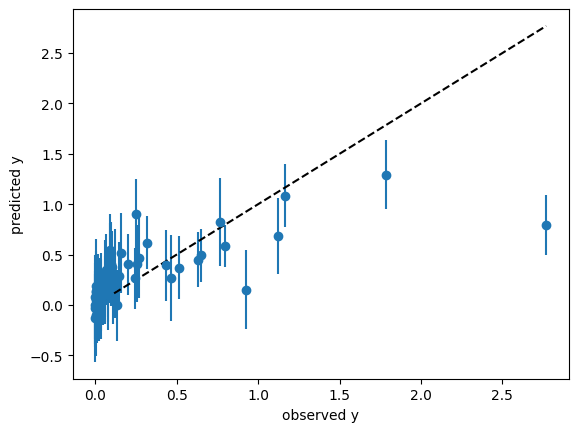

In [44]:
cross_validation(train_x,train_y)

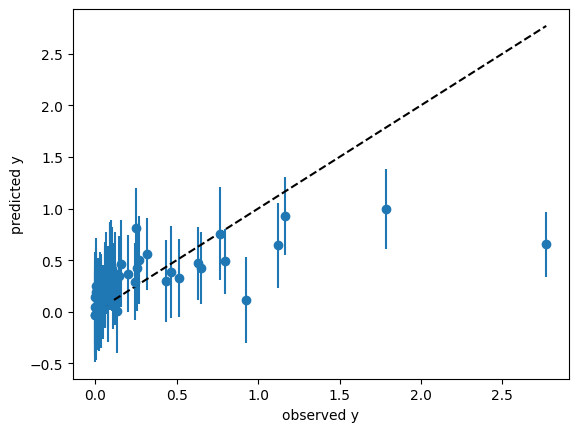

In [45]:
cross_validation(train_x,train_y,0.5)

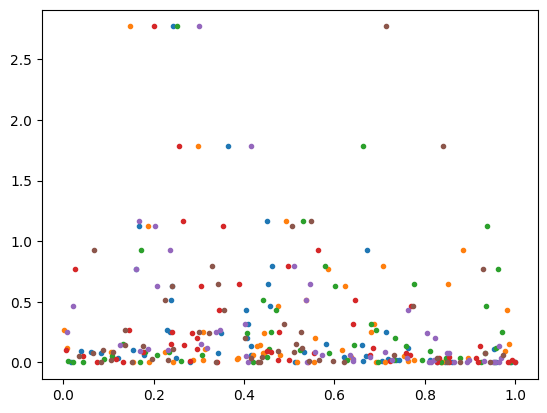

In [46]:
plt.plot(train_x.detach().cpu().numpy(),
         train_y.detach().cpu().numpy(),'.')

In [47]:
train_x

tensor([[0.0611, 0.2246, 0.2343, 0.1771, 0.5561, 0.1094],
        [0.4609, 0.7084, 0.5798, 0.4967, 0.5104, 0.3295],
        [0.7182, 0.3845, 0.0898, 0.1175, 0.6402, 0.1968],
        [0.5124, 0.7118, 0.9249, 0.9997, 0.8927, 0.8767],
        [0.8450, 0.1544, 0.1705, 0.9842, 0.8127, 0.4358],
        [0.4143, 0.4284, 0.7578, 0.9225, 0.9643, 0.1760],
        [0.9539, 0.3134, 0.4544, 0.2956, 0.1875, 0.2433],
        [0.3493, 0.4441, 0.4069, 0.2859, 0.8036, 0.3218],
        [0.3639, 0.2985, 0.6635, 0.2552, 0.4144, 0.8396],
        [0.7418, 0.2865, 0.7929, 0.5001, 0.8977, 0.1051],
        [0.5809, 0.9867, 0.1315, 0.2391, 0.3047, 0.5158],
        [0.4514, 0.4929, 0.5301, 0.2647, 0.1671, 0.5482],
        [0.2380, 0.5374, 0.4422, 0.6454, 0.5376, 0.2245],
        [0.6632, 0.8439, 0.0109, 0.2807, 0.9301, 0.5438],
        [0.8123, 0.7750, 0.7308, 0.9924, 0.7282, 0.2328],
        [0.9997, 0.5540, 0.4200, 0.5419, 0.8642, 0.4312],
        [0.1213, 0.8956, 0.8784, 0.9128, 0.9688, 0.4150],
        [0.409

(array([37.,  4.,  4.,  1.,  2.,  0.,  1.,  0.,  0.,  1.]),
 array([1.06732378e-04, 2.77083255e-01, 5.54059779e-01, 8.31036302e-01,
        1.10801282e+00, 1.38498935e+00, 1.66196587e+00, 1.93894239e+00,
        2.21591892e+00, 2.49289544e+00, 2.76987196e+00]),
 <BarContainer object of 10 artists>)

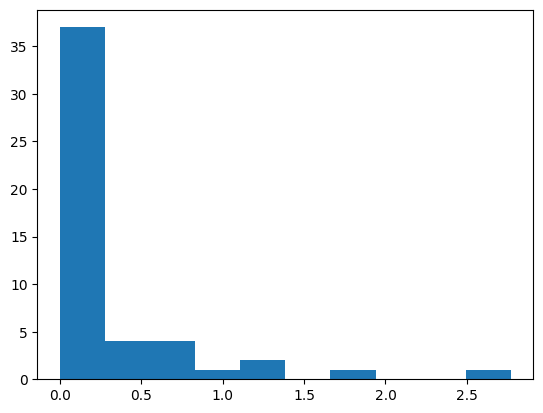

In [48]:
plt.hist(train_y.cpu().numpy())